In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

path = r'C:\Users\DELL\Desktop\python_project_aiml_logicmojo_dataset\\' 

# Load all datasets 
customers = pd.read_csv(path + 'customers.csv')
print("-----customers info-----")
print("Missing values in Customers:\n", customers.isnull().sum())
 #Inspect structure using .head(), .info(), .describe() 
print(customers.head())         
print(customers.info())
print(customers.describe())

orders = pd.read_csv(path + 'orders.csv')
print("--- Orders Info ---")
print(orders.info())
print("Missing values in Orders:\n", orders.isnull().sum())

payments = pd.read_csv(path + 'payments.csv')
print("--- Payment Info ---")
print(payments.info())
print("Missing values in Payments:\n", payments.isnull().sum())

category_translation = pd.read_csv(path + 'category_translation.csv')
print("--- category_translation ---")
# print(category_translation.info())
print("Missing values in Orders:\n", category_translation.isnull().sum())

location = pd.read_csv(path + 'location.csv')
print("--- location  ---")
print(location.info())
print("Missing values in Orders:\n", location.isnull().sum())

order_item = pd.read_csv(path + 'order_item.csv')
print("--- orderitem  ---")
print(order_item.info())
print("Missing values in Orders:\n", order_item.isnull().sum())


products = pd.read_csv(path + 'products.csv')
print("--- Products  ---")
print(products.info())

reviews = pd.read_csv(path + 'reviews.csv')
print("--- Reviews  ---")
print(reviews.info())

sellers = pd.read_csv(path + 'sellers.csv')
print("--- Sellers  ---")
print(sellers.info())
print("Missing values in Orders:\n", sellers.isnull().sum())


-----customers info-----
Missing values in Customers:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4  

In [ ]:
# --- STEP 2: DATA CLEANING AND PREPROCESSING ---
# 1. Handle missing values appropriately
# Use the estimated delivery date to fill missing actual delivery dates to preserve data for analysis
# Fill Missing Values with zero for Order table

orders['order_delivered_customer_date'] = orders['order_delivered_customer_date'].fillna(orders['order_estimated_delivery_date'])

# Impute missing approval dates with the purchase timestamp
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])
orders['order_delivered_carrier_date'] = orders['order_delivered_carrier_date'].fillna(orders['order_approved_at'])
print("Missing values in Orders:\n", orders.isnull().sum())



Missing values in Orders:
 order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


In [48]:
# Fill Missing Values with zero for Product table
products['product_category_name'] = products['product_category_name'].fillna('unknown')


products['product_name_lenght'] = products['product_name_lenght'].fillna(products['product_name_lenght'].median())

products['product_description_lenght'] = products['product_description_lenght'].fillna(products['product_description_lenght'].median())
products['product_photos_qty'] = products['product_photos_qty'].fillna(products['product_photos_qty'].median())
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())
products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm'].median())
products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm'].median())
products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm'].median())

# print(products)
print("Missing values in Products :\n", products.isnull().sum())
df

Missing values in Products :
 product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,8.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,8.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,8.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813.0,...,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570.0,belo horizonte,SP,perfumery,13.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265.0,...,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58,14840.0,guariba,SP,auto,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722.0,...,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01,2018-03-02 17:50:01,17602.0,tupa,SP,baby,22.0
119139,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920.0,...,5.0,NaN,Foi entregue antes do prazo.,2017-09-22,2017-09-22 23:10:57,8290.0,sao paulo,SP,home_appliances_2,24.0
119140,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685.0,...,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,37175.0,ilicinea,MG,computers_accessories,17.0
119141,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685.0,...,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,37175.0,ilicinea,MG,computers_accessories,17.0


In [ ]:
# Fill Missing Values with zero for Review table

reviews['review_comment_title']=reviews['review_comment_title'].fillna(reviews['review_score'])
reviews['review_comment_message']=reviews['review_comment_message'].fillna(reviews['review_score'])



print("Missing values in Reviews :\n", reviews.isnull().sum())


Missing values in Reviews :
 review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


In [20]:
# Remove duplicate records 
# Checking total duplcate customer 
print(f"Total Customer duplicates: {customers.duplicated().sum()}")

# Remove duplicates based on the unique customer ID
# keep='first' ensures we keep the original entry and remove the copies
customers.drop_duplicates(subset='customer_unique_id', keep='first', inplace=True)
print(f"Total Customer unique id duplicates: {customers.duplicated().sum()}")

# Verify that duplicates are gone
print(f"Remaining unique customers: {customers['customer_unique_id'].nunique()}")
print(f"Total rows in customer table: {len(customers)}")


# checking duplicate records in location
print(f"Total location duplicates: {location.duplicated().sum()}")


# checking duplicate order
print(f"Total  Order duplicates: {orders.duplicated().sum()}")
order_dup = orders.duplicated(subset='order_id').sum()
print(f"Number of duplicate Order Id: {order_dup}")


# Checking duplicate record in Product and Product_id
print(f"Total  Product duplicates: {products.duplicated().sum()}")
prod_dup = products.duplicated(subset='product_id').sum()
print(f"Number of duplicate Product Id: {prod_dup}")


# # checking Seller table duplicates
sellers.drop_duplicates(subset='seller_id', inplace=True)
print(f"Total  Sellers duplicates: {sellers.duplicated().sum()}")
sell_dup = sellers.duplicated(subset='seller_id').sum()
print(f"Number of duplicate Seller Id: {sell_dup}")

# category_translation.drop_duplicates(subset='seller.id', inplace=True)
print(f"Total  category_translation duplicates: {category_translation.duplicated().sum()}")



Total Customer duplicates: 0
Total Customer unique id duplicates: 0
Remaining unique customers: 96096
Total rows in customer table: 96096
Total location duplicates: 261831
Total  Order duplicates: 0
Number of duplicate Order Id: 0
Total  Product duplicates: 0
Number of duplicate Product Id: 0
Total  Sellers duplicates: 0
Number of duplicate Seller Id: 0
Total  category_translation duplicates: 0


In [21]:
## Convert date columns to datetime format

print("Conversion of order table's columns to reqd timestamp")
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',

]

# Perform conversion
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Verify the timestamp change in order
print(orders[date_cols].dtypes)
print(orders.info())

print("Conversion of review table's columns to read timestamp")
data_rev_col = [ 'review_creation_date',
            'review_answer_timestamp',]
for col in data_rev_col:
    reviews[col] = pd.to_datetime(reviews[col], errors='coerce')


# Verify the timestamp change in review
print(reviews[data_rev_col].dtypes)
print(reviews.info())

print("Conversion of order item table's shipping_limit_date column to reqd timestamp")
order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'])
print(order_item.info())



Conversion of order table's columns to reqd timestamp
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-nu

In [24]:
# Check for negative prices or freight (which shouldn't exist)
invalid_prices = order_item[(order_item['price'] <= 0) | (order_item['freight_value'] < 0)]

# Check for negative payment values
invalid_payments = payments[payments['payment_value'] < 0]

print(f"Rows with price issues: {len(invalid_prices)}")
print(f"Rows with payment issues: {len(invalid_payments)}")


# Check for "impossible" dates where the estimated delivery is BEFORE the purchase
invalid_dates = orders[orders['order_estimated_delivery_date'] < orders['order_purchase_timestamp']]

print(f"Number of illogical delivery estimates: {len(invalid_dates)}")

Rows with price issues: 0
Rows with payment issues: 0
Number of illogical delivery estimates: 0


In [33]:
# Step 3: Data Integration (Critical Component)

df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(order_item, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(reviews, on="order_id", how="left")
df = df.merge(sellers, on="seller_id", how="left")
df = df.merge(category_translation, on="product_category_name", how="left")
df.shape
df.head()
df.to_csv("master_table.csv", index=False)
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813.0,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570.0,belo horizonte,SP,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265.0,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58,14840.0,guariba,SP,auto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722.0,...,29bb71b2760d0f876dfa178a76bc4734,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01,2018-03-02 17:50:01,17602.0,tupa,SP,baby
119139,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920.0,...,371579771219f6db2d830d50805977bb,5.0,NaN,Foi entregue antes do prazo.,2017-09-22,2017-09-22 23:10:57,8290.0,sao paulo,SP,home_appliances_2
119140,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685.0,...,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,37175.0,ilicinea,MG,computers_accessories
119141,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685.0,...,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,37175.0,ilicinea,MG,computers_accessories


In [ ]:

# Difference between purchase and actual delivery
df['delivery_time'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days



# ---  Number of Items per Order ---
# We group by order_id and count the number of products
items_per_order = df.groupby('order_id')['product_id'].count().reset_index()
items_per_order.columns = ['order_id', 'items_count']

# ---  Total Order Value ---
# It is best to use the payments table for the total value (includes tax, freight, etc.)
# We take the max of payment_value per order_id if payments are already summed, 
# or sum them if they are split by installments.
order_value = df.groupby('order_id')['payment_value'].sum().reset_index()
order_value.columns = ['order_id', 'total_order_value']

# Merge these back into the master dataframe or a new order-level dataframe
order_features = items_per_order.merge(order_value, on='order_id')

# --- D. Customer Purchase Frequency ---
# How many unique orders did each unique customer place?
customer_freq = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_freq.columns = ['customer_unique_id', 'purchase_frequency']

# --- E. Customer Lifetime Value (CLV Approximation) ---
# The total amount of money spent by the unique customer across all orders
customer_clv = df.groupby('customer_unique_id')['payment_value'].sum().reset_index()
customer_clv.columns = ['customer_unique_id', 'clv']

# --- F. Average Order Value (AOV) per Customer ---
# Total Spent / Total Orders
customer_metrics = customer_clv.merge(customer_freq, on='customer_unique_id')
customer_metrics['avg_order_value'] = customer_metrics['clv'] / customer_metrics['purchase_frequency']

# Final Customer 360 Table
customer_360 = customer_metrics.copy()

# Add average delivery time for each customer (if you want to see who experiences delays)
avg_delivery_cust = df.groupby('customer_unique_id')['delivery_time'].mean().reset_index()
avg_delivery_cust.columns = ['customer_unique_id', 'avg_delivery_time']

customer_360 = customer_360.merge(avg_delivery_cust, on='customer_unique_id')

print("Feature Engineering Complete!")
print(customer_360.head())
df


# items_per_order
# order_value
# order_features

# customer_freq
# customer_clv



customer_metrics

# customer_360

# avg_delivery_cust

# customer_360

Feature Engineering Complete!
                 customer_unique_id     clv  purchase_frequency  \
0  0000366f3b9a7992bf8c76cfdf3221e2  141.90                   1   
1  0000b849f77a49e4a4ce2b2a4ca5be3f   27.19                   1   
2  0000f46a3911fa3c0805444483337064   86.22                   1   
3  0000f6ccb0745a6a4b88665a16c9f078   43.62                   1   
4  0004aac84e0df4da2b147fca70cf8255  196.89                   1   

   avg_order_value  avg_delivery_time  
0           141.90                6.0  
1            27.19                3.0  
2            86.22               25.0  
3            43.62               20.0  
4           196.89               13.0  


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,8.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,8.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,...,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,9350.0,maua,SP,housewares,8.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813.0,...,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,31570.0,belo horizonte,SP,perfumery,13.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265.0,...,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58,14840.0,guariba,SP,auto,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119138,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722.0,...,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01,2018-03-02 17:50:01,17602.0,tupa,SP,baby,22.0
119139,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920.0,...,5.0,NaN,Foi entregue antes do prazo.,2017-09-22,2017-09-22 23:10:57,8290.0,sao paulo,SP,home_appliances_2,24.0
119140,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685.0,...,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,37175.0,ilicinea,MG,computers_accessories,17.0
119141,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5312c8b157bb7be58ae360ef43c,28685.0,...,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,37175.0,ilicinea,MG,computers_accessories,17.0


In [37]:
# --- New vs Repeat Customers ---
repeat_customers = (customer_360['purchase_frequency'] > 1).sum()
new_customers = (customer_360['purchase_frequency'] == 1).sum()
print(f"Repeat Customers: {repeat_customers} | New Customers: {new_customers}")

# --- High-value vs Low-value (Using Quantiles) ---
# We define high-value as the top 10% of spenders
top_10_percent_threshold = customer_360['clv'].quantile(0.90)
customer_360['value_segment'] = customer_360['clv'].apply(lambda x: 'High-Value' if x >= top_10_percent_threshold else 'Low-Value')

# --- Geographic Distribution ---
geo_dist = df.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False)

# --- Monthly Revenue Trends ---
monthly_revenue = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum()

# --- Order Volume Trends ---
monthly_orders = df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['order_id'].nunique()

# --- Peak Sales Periods (Day of Week) ---
peak_days = df.groupby(df['order_purchase_timestamp'].dt.day_name())['order_id'].nunique().sort_values(ascending=False)

# --- Top-selling Categories (By Volume) ---
top_cats_vol = df['product_category_name_english'].value_counts().head(10)

# --- Revenue Contribution by Category ---
cat_revenue = df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False)

# --- Product Demand Distribution ---
# Check how many products make up the bulk of sales (Pareto Principle)
product_demand = df['product_id'].value_counts()


# --- Top-performing Sellers (Revenue) ---
top_sellers = df.groupby('seller_id')['payment_value'].sum().sort_values(ascending=False).head(10)

# --- Seller Contribution to Revenue ---
# Calculate what % of revenue the top 10 sellers provide
top_10_seller_rev = top_sellers.sum()
total_rev = df['payment_value'].sum()
print(f"Top 10 sellers contribute {(top_10_seller_rev/total_rev)*100:.2f}% of total revenue")

# --- Distribution of Review Scores ---
review_dist = df['review_score'].value_counts(normalize=True).sort_index()

# --- Relationship Between Delivery Time and Ratings ---
# Correlation check
correlation = df[['delivery_time', 'review_score']].corr().iloc[0,1]
print(f"Correlation between delivery time and review score: {correlation:.2f}")

# --- Identification of Dissatisfaction Patterns ---
# See the average delivery time for 1-star reviews vs 5-star reviews
dissatisfaction_pattern = df.groupby('review_score')['delivery_time'].mean()

Repeat Customers: 0 | New Customers: 96096
Top 10 sellers contribute 13.98% of total revenue
Correlation between delivery time and review score: -0.30


C:\Users\DELL\AppData\Local\Temp\ipykernel_20288\1605584213.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_dist.index, y=state_dist.values, palette='viridis')


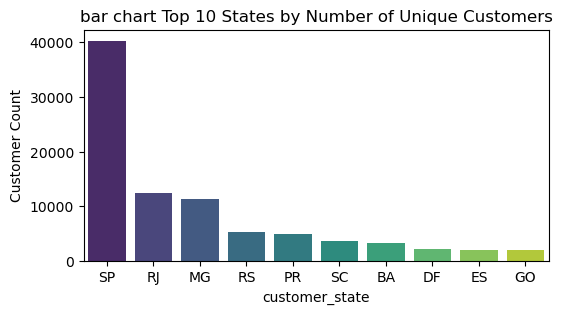

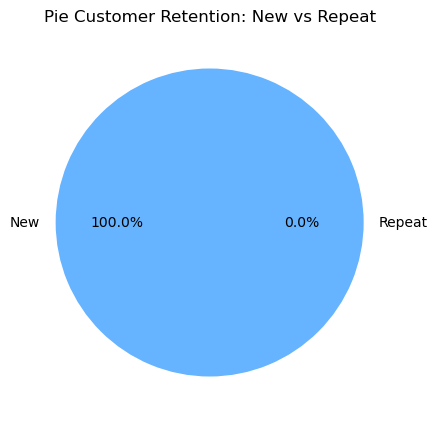

In [46]:
#step 6 

import matplotlib.pyplot as plt
import seaborn as sns

# --- Geographic Distribution (Top 10 States) ---
plt.figure(figsize=(6, 3))
state_dist = df.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False).head(10)
sns.barplot(x=state_dist.index, y=state_dist.values, palette='viridis')
plt.title('bar chart Top 10 States by Number of Unique Customers')
plt.ylabel('Customer Count')
plt.show()

# --- New vs Repeat Customers Pie Chart ---
plt.figure(figsize=(5, 5))
plt.pie([new_customers, repeat_customers], labels=['New', 'Repeat'], autopct='%1.1f%%', colors=['#66b3ff','#99ff99'])
plt.title('Pie Customer Retention: New vs Repeat')
plt.show()

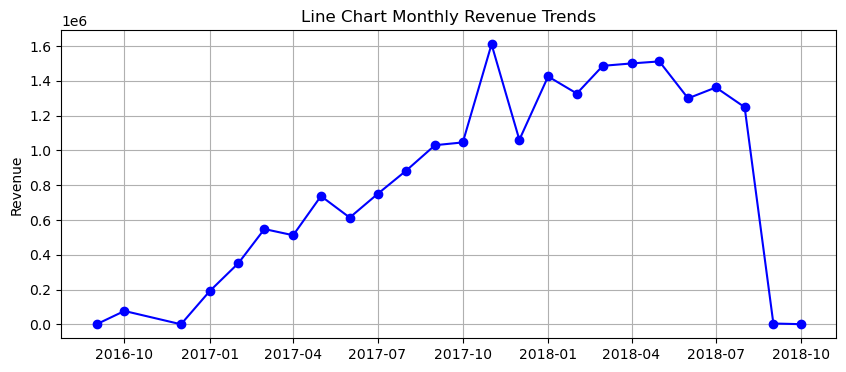

In [47]:
#Revenue and Order Trends Line Chart

# --- Monthly Revenue Trend ---
# Convert period back to timestamp for plotting
monthly_rev_plot = monthly_revenue.copy()
monthly_rev_plot.index = monthly_rev_plot.index.to_timestamp()

plt.figure(figsize=(10, 4))
plt.plot(monthly_rev_plot.index, monthly_rev_plot.values, marker='o', linestyle='-', color='b')
plt.title('Line Chart Monthly Revenue Trends')
plt.grid(True)
plt.ylabel('Revenue')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_20288\2308051946.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cat_rev.values, y=top_cat_rev.index, palette='magma')


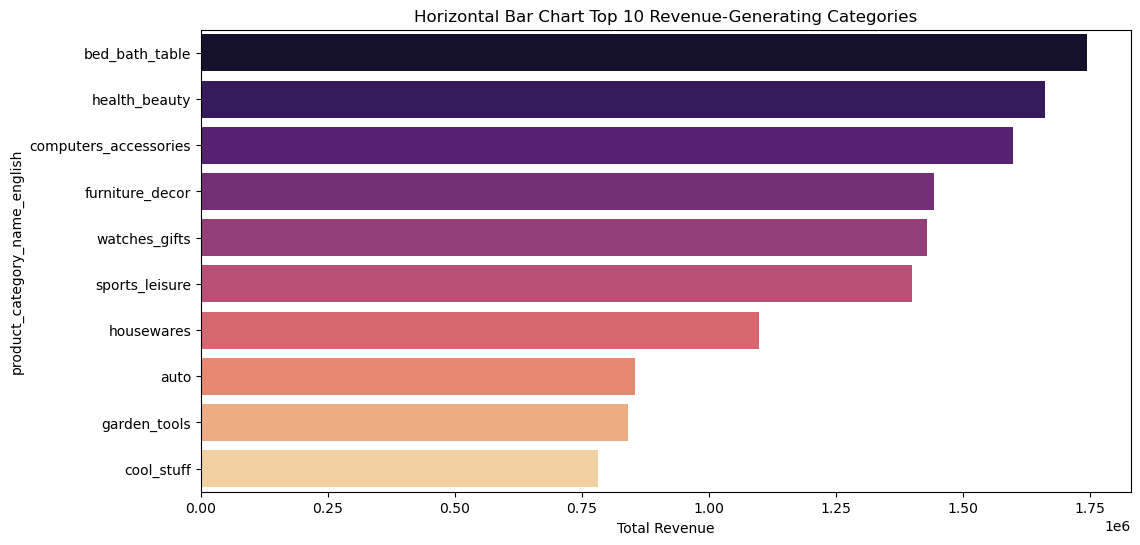

In [43]:
# Product & Seller Analysis Horizontal Bar Chart
# These charts identify your "Profit Drivers.

# --- Top 10 Product Categories by Revenue ---
plt.figure(figsize=(12, 6))
top_cat_rev = df.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cat_rev.values, y=top_cat_rev.index, palette='magma')
plt.title('Horizontal Bar Chart Top 10 Revenue-Generating Categories')
plt.xlabel('Total Revenue')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_20288\2557004432.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='review_score', palette='RdYlGn')


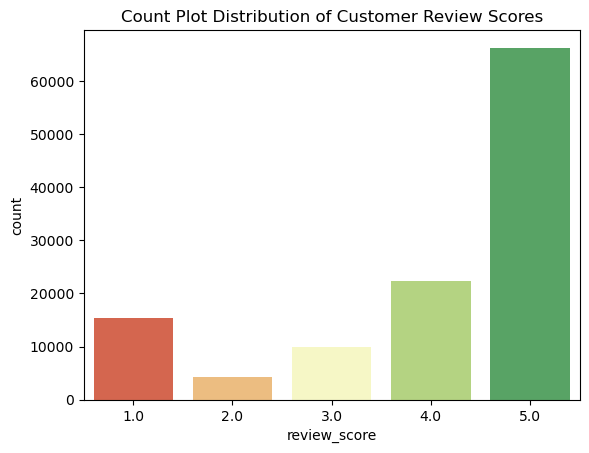

C:\Users\DELL\AppData\Local\Temp\ipykernel_20288\2557004432.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='review_score', y='delivery_time', data=df, showfliers=False, palette='RdYlGn')


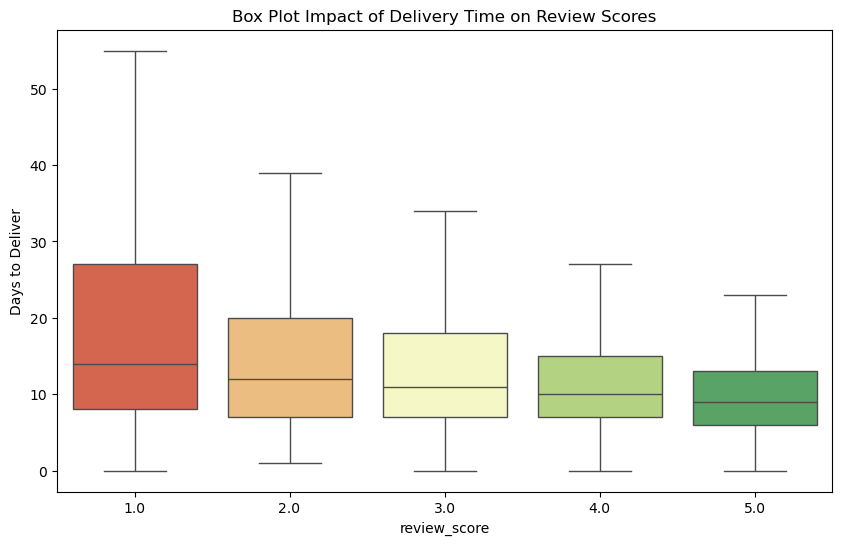

In [44]:
# Review and Satisfaction Analysis Count Plot (Bar)

# --- Distribution of Review Scores ---
sns.countplot(data=df, x='review_score', palette='RdYlGn')
plt.title('Count Plot Distribution of Customer Review Scores')
plt.show()

# --- Delivery Time vs. Review Score ---Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='delivery_time', data=df, showfliers=False, palette='RdYlGn')
plt.title('Box Plot Impact of Delivery Time on Review Scores')
plt.ylabel('Days to Deliver')
plt.show()